In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

from pathlib import Path

In [2]:
mode = "FULL_2D" # "RADIAL_ONLY" or "FULL_2D"
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, mode)

In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j


In [3]:
# mesh_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Meshes")
mesh_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Meshes")
mesh_save_dir.mkdir(parents=True, exist_ok=True)

# figure_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Figures")
figure_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Figures")
figure_save_dir.mkdir(parents=True, exist_ok=True)


solver.build_physics_Stix_B_field()
mesh = solver.build_mesh_with_PMLs()
# print('num_vertices = ', mesh.nv)

GF_E_field, _, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode, )

Lx_pml = 1.000e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 50.0, Sx_norm_max:5.00e+00, h_min_pml_radial: 3.61e-05
Sz_norm_max: 5.83e+00, h_min_pml_toroidal: 3.09e-05, h_min_pml_corner: 2.35e-05

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_plasma resolution : 1.12760e-03 m
#DoFs = 2448529 (= number of mesh points).
kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 0.0135, window_size_toroidal: 0.0608
  --> Radial Gamma_R: 1.33e-01, computed at z=2.622e-03m
  --> Toroidal Gamma_T: 9.60e-01, computed at x=1.966e-03m
type(diag_data): <class 'dict'>
diag_data: {'x_target_R': 0.019, 'peak_z_R': np.float64(0.0026217545125801476), 'window_size_radial': np.float64(0.013531183537789516), 'z_target_T': 0.19243434804054055, 'peak_x_T': np.float64(0.0019657657657657663), 'windo

In [4]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260604_161013
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260604_161013


--- Extracting 2D Wave Map ---
[run 2D E map]
Lx_plasma: 2.00e-02m, Lx_pml: 1.00e-02m, Lx_tot: 3.00e-02m
Lz_plasma: 2.03e-01m, Lz_pml: 4.05e-02m, Lz_tot: 2.84e-01m
params recover in run_2D_wave_map
  --> Safely interpolating FEM fields onto structured grid...
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
PP_run_n_save: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260604_161013/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui
key: x_target_R, type(key): <class 'str'>, val: 0.019
key: peak_z_R, type(key): <class 'str'>, val: 0.0026217545125801476
key: window_size_radial, type(key): <class 'str'>, val: 0.013531183537789516
key: z_target_T, type(key): <class 'str'>, val: 0.19243434804054055
key: peak_x_T, type(key): <class 'str'>, val: 0.0019657657657657663
key: window_size_toroidal, type(key): <class 'str'>, 

KeyError: 'Unable to synchronously open object (invalid identifier type to function)'

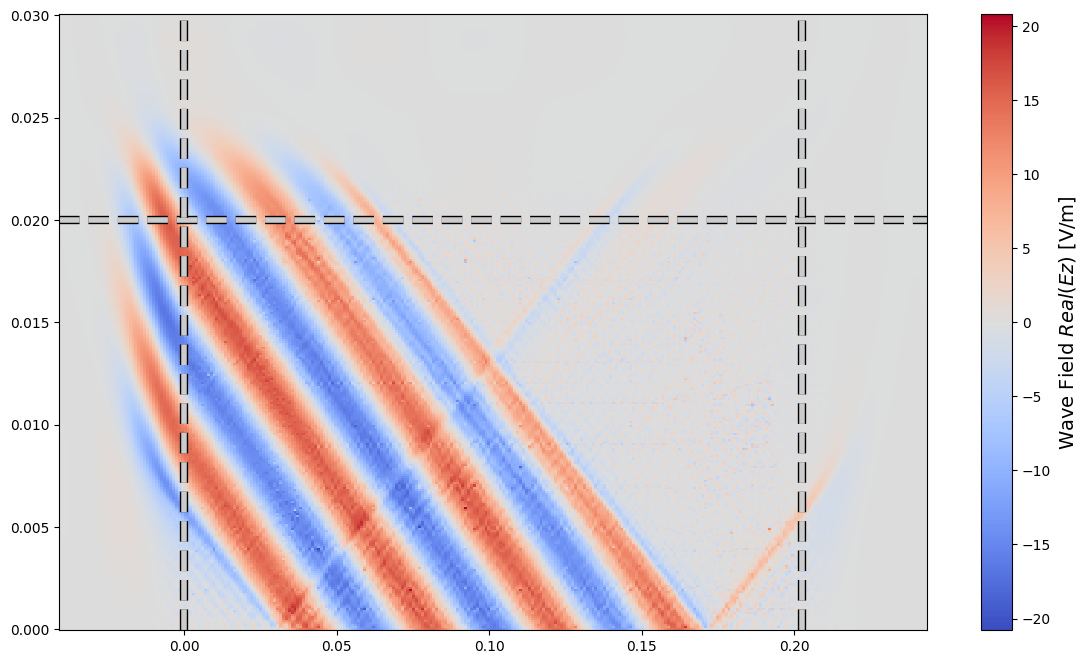

In [5]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, mode, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, mode, component='Ez', value_type='real', plot_poynting=False, show_windows=True)

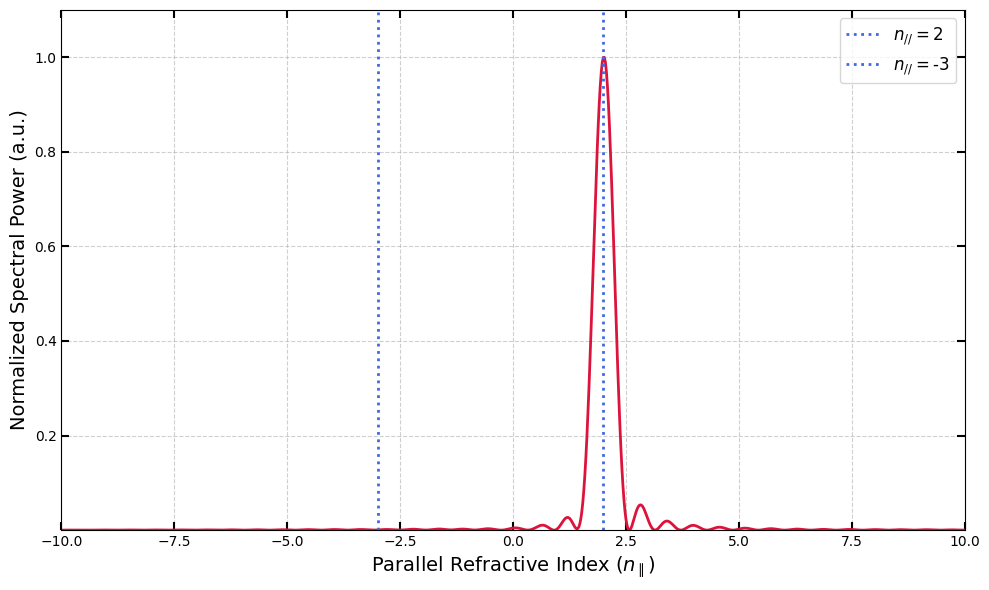

In [ ]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, mode, x_eval=0.001)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import gc
from ngsolve import *
from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

def run_2D_pml_comparative_scan(base_cfg, scan_groups):
    """
    Rigorously sweeps PML parameters simultaneously for Radial and Toroidal dimensions.
    Extracts both Gamma_R and Gamma_T, and plots them on the same graph for direct comparison.
    
    :param base_cfg: The baseline configuration dictionary (cfg.__dict__).
    :param scan_groups: Dictionary defining the parameter pairs to scan together.
    """
    print("=====================================================")
    print("  STARTING 2D TOROIDAL & RADIAL PML SENSITIVITY SCAN")
    print("=====================================================")
    
    results = {}

    for group_name, (param_values, param_x, param_z) in scan_groups.items():
        print(f"\n---> Scanning Group: {group_name} ({param_x} & {param_z})")
        gamma_R_array = []
        gamma_T_array = []
        
        for val in param_values:
            # 1. Safely Deep Copy the baseline config
            scan_cfg = {}
            for key, value in base_cfg.items():
                if isinstance(value, dict) and not key.startswith('__'):
                    scan_cfg[key] = copy.deepcopy(value)
            
            # 2. Inject BOTH parameters simultaneously
            for param_name in [param_x, param_z]:
                if param_name in ['Sx_r', 'Sz_r']:
                    scan_cfg['PML'][param_name] = val
                elif param_name in ['Sx_im', 'Sz_im']:
                    scan_cfg['PML'][param_name] = val
                elif param_name in ['px', 'pz']:
                    scan_cfg['PML'][param_name] = val
                elif param_name in ['Lx_pml_ratio', 'Lz_pml_ratio']:
                    # Dynamically compute lambda_perp and lambda_para
                    c0 = scan_cfg['CONST']['c0']
                    freq = scan_cfg['WAVE']['freq_LH']
                    lambda0 = c0 / freq
                    
                    # Temporary solver to get physics roots
                    temp_solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="FULL_2D")
                    n_para, n_perp_p, _ = temp_solver.compute_physics_parameters()
                    del temp_solver
                    
                    if param_name == 'Lx_pml_ratio':
                        lambda_perp = lambda0 / np.abs(n_perp_p.real)
                        scan_cfg['DOMAIN']['Lx_pml'] = val * lambda_perp
                        scan_cfg['DOMAIN']['Lx_tot'] = scan_cfg['DOMAIN']['Lx_plasma'] + scan_cfg['DOMAIN']['Lx_pml']
                    elif param_name == 'Lz_pml_ratio':
                        lambda_para = lambda0 / np.abs(n_para)
                        scan_cfg['DOMAIN']['Lz_pml'] = val * lambda_para
                        scan_cfg['DOMAIN']['Lz_tot'] = scan_cfg['DOMAIN']['Lz_plasma'] + 2 * scan_cfg['DOMAIN']['Lz_pml']
                elif param_name == 'ppw_pml':
                    scan_cfg['PML']['ppw_pml'] = val
                else:
                    raise ValueError(f"Unknown scan parameter: {param_name}")

            # 3. Initialize and Run the 2D Physics Solver
            solver = None
            mesh = None
            gfu = None
            Gamma_R, Gamma_T = 1.0, 1.0 # Default to total reflection on failure
            
            try:
                solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="FULL_2D")
                solver.build_physics_Stix_B_field()
                mesh = solver.build_mesh_with_PMLs()
                
                # Solve Helmholtz
                gfu, _, Gamma_R, Gamma_T = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode="FULL_2D")
            except Exception as e:
                print(f"  [Val = {val:.4e}] -> SOLVER FAILED: {e}")
                
            finally:
                gamma_R_array.append(Gamma_R)
                gamma_T_array.append(Gamma_T)
                
                # 5. ABSOLUTE MEMORY DESTRUCTION
                if mesh is not None: del mesh
                if gfu is not None: del gfu
                if solver is not None: del solver
                gc.collect()

        results[group_name] = (param_values, gamma_R_array, gamma_T_array)
        
        # 6. Generate Comparative Plot
        plt.figure(figsize=(10, 6))
        
        # Plot Radial Gamma (Blue)
        plt.plot(param_values, gamma_R_array, marker='o', linestyle='-', color='royalblue', lw=2.5, label=rf'Radial ($\Gamma_R$) - {param_x}')
        
        # Plot Toroidal Gamma (red)
        plt.plot(param_values, gamma_T_array, marker='s', linestyle='-', color='crimson', lw=2.5, label=rf'Toroidal ($\Gamma_T$) - {param_z}')
        
        plt.yscale('log')
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        
        # Dynamic axis labels
        xlabel_str = group_name
        if 'Ratio' in group_name:
            xlabel_str = r"PML Depth Ratio ($L_{pml} / \lambda$)"
        elif 'Imaginary' in group_name:
            xlabel_str = r"Imaginary Damping ($S^{im}$)"
        elif 'Polynomial' in group_name:
            xlabel_str = r"Polynomial Degree ($p$)"
            
        plt.xlabel(xlabel_str, fontsize=14, fontweight='bold')
        plt.ylabel(r"Reflection Coefficient ($\Gamma$)", fontsize=14, fontweight='bold')
        plt.title(f"2D PML Comparative Sensitivity: {group_name}", fontsize=16)
        plt.tick_params(direction='in', length=6, width=1.5, bottom=True, top=True, right=True, left=True)
        plt.legend(fontsize=12, loc='upper right', framealpha=0.9)
        
        plt.tight_layout()
        plt.show()

    return results

# ====================================================================
# EXECUTION BLOCK
# ====================================================================

# Define the logical groupings. 
# Format: 'Plot Title': (NumPy Array of values, 'Radial Param Name', 'Toroidal Param Name')
scans_to_run_2D = {
    'Depth Ratio': (np.linspace(0.5, 4.0, 15), 'Lx_pml_ratio', 'Lz_pml_ratio'),
    'Imaginary Damping': (np.linspace(0.5, 8.0, 20), 'Sx_im', 'Sz_im'),
    'Polynomial Smoothing': (np.linspace(1.0, 4.0, 15), 'px', 'pz')
}

# Run the comparative scan
# Ensure you are passing cfg.__dict__ as the base configuration
scan_results_2D = run_2D_pml_comparative_scan(cfg.__dict__, scans_to_run_2D)

  STARTING 2D TOROIDAL & RADIAL PML SENSITIVITY SCAN

---> Scanning Group: Depth Ratio (Lx_pml_ratio & Lz_pml_ratio)
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 4.510e-03m
Lz_plasma = 2.03e-01m, Lz_pml = 1.22e-01m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 50.0, Sx_norm_max:5.00e+00, h_min_pml_radial: 3.61e-05
Sz_norm_max: 5.83e+00, h_min_pml_toroidal: 3.09e-05, h_min_pml_corner: 2.35e-05

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_plasma resolution : 1.12760e-03 m
#DoFs = 3261900 (= number of mesh points).
kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 0.0135, windo